<a href="https://colab.research.google.com/github/AshrithSagar/CP260-RP-2025/blob/main/5_Lab_CP260_2025_Q.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Lab5: Understanding Image Metrology**

You are given an image of a tetrahedron and a cuboid
on a standard A4 sheet of paper (20.8cm x 29.6cm)

You need to extract the length of the two objects
and the angle of the vertices at their faces.

You can assume that all sides of the cuboid and the tetrahedron are of the same length.

In [ ]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
%%capture
# This package helps to download files from google drive
!pip install gdown

In [ ]:
#utility functions
def unit_vector(vector):
  """ Returns the unit vector of the vector
  """
  try:
    return vector / np.linalg.norm(vector)
  except ZeroDivisionError:
    print(f"vector={vector} has to be non-zero")
    return 0

def angle_between(v1, v2):
    """ Returns the angle in radians between vectors 'v1' and 'v2'::

            >>> angle_between((1, 0, 0), (0, 1, 0))
            1.5707963267948966
            >>> angle_between((1, 0, 0), (1, 0, 0))
            0.0
            >>> angle_between((1, 0, 0), (-1, 0, 0))
            3.141592653589793
    """
    v1_u = unit_vector(v1)
    v2_u = unit_vector(v2)
    return np.arccos(np.clip(np.dot(v1_u, v2_u), -1.0, 1.0))

In [ ]:
%%capture
# download the image file from shared link on google drive
import gdown
#url = 'https://drive.google.com/uc?id=1o25MqsrYRyMDOQLOororNncEC3KMziqp'
url='https://drive.google.com/uc?id=1sSRLTmRcU_rlM2yFz2zLyDcATtojeHID'
#url='https://drive.google.com/uc?id=1frpq1lnyIEzSntbyGcjg4-7b4c0c59md'
output = 'Toys.jpg'
gdown.download(url, output, quiet=False)

(2992, 2992, 3)


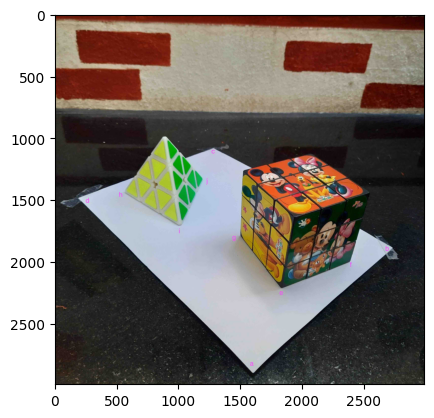

In [ ]:
img = cv.cvtColor(cv.imread('Toys.jpg'), cv.COLOR_BGR2RGB)
plt.imshow(img)
print(img.shape)

You now need to identify the pixel coordinates of the vertices
marked in the image.

You are free to use any tool.

One convenient tool is at
 https://pixspy.com

You can also download the same image from :
https://drive.google.com/drive/folders/1LsoITE13tmyppPN7kwtE8uJCcRIqyu3_

In [ ]:
# Q1 Your answer here
# Find the coordinates of the points a-j and replace 'pass'
# with your answers
a=[1598,2907,1]

###################
#YOUR CODE HERE


In [ ]:
#Q2: Find the 3x3 matrix H_up which will remove the projective distortion
#Determine the vanishing points and the  vanishing line and construct the
#matrix

lab = np.cross(a, b)

###################
#YOUR CODE HERE

###################


print("The vanishing line is:",l12)

# Construct the matrix H_up for undoing projectivity
###################
#YOUR CODE HERE

###################

#check if it maps vanishing line to line at infinity
print("H_up maps the vanishing line to:",np.linalg.inv(H_up).T @ l12)

The vanishing line is: [-7.50395093e-05  1.53277947e-03  1.00000000e+00]
H_up maps the vanishing line to: [0. 0. 1.]


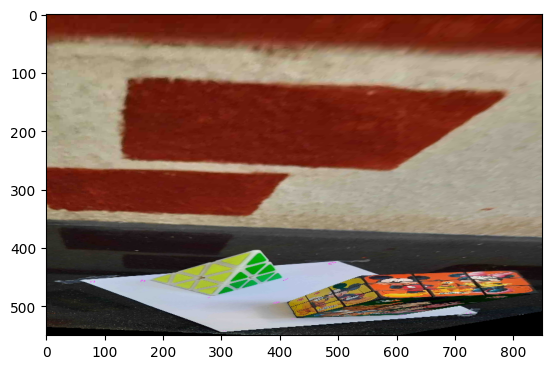

In [ ]:
img_up = cv.warpPerspective(img,H_up ,dsize=(850,550))
plt.imshow(img_up)

Identify two line-pairs in the above  image which we know are orthogonal in the original scene.

Let the two line pairs be $l_o, m_o$ and $n_0, q_0$ in original scene and their maps here are $l, m$ and $n,q$ respectively in the above image

Let the affinity portion of the homography be:
$
H_A = \begin{bmatrix}
k_1 & k_2 & 0\\
0 & k_3 & 0\\
0 & 0 & 1 \\
\end{bmatrix} = \begin{bmatrix} K & 0 \\ 0 & 1 \\ \end{bmatrix}
$

Then for first line pair:

$
l_o^T m_o = l^T \begin{bmatrix} K^T K && 0 \\ 0 && 0 \\ \end{bmatrix} m = 0
$

Let
$
g = K^T K = \begin{bmatrix} g_0 && g_1 \\ g_1 && g_2 \\ \end{bmatrix} = \begin{bmatrix} k_1^2 && k_1 k_2 \\ k_1 k_2 && k_3^2 \\ \end{bmatrix}
$

Then
$
l_0 m_0 g_0 + (l_1 m_0 + l_0 m_1)g_1 + l_1 m_1 g_2 = 0
$


Similar equation for second line pair yields:

$
\begin{bmatrix}
l_0 m_0 && l_1 m_0 + l_0 m_1 && l_1 m_1 \\
n_0 q_0 && n_1 q_0 + n_0 q_1 && n_1 q_1 \\
\end{bmatrix} \begin{bmatrix} g_0 \\ g_1 \\ g_2 \\ \end{bmatrix} = 0
$

Use SVD to solve the above equation to find $g$, which is the singular vector for the singular value 0.






In [ ]:
#Q3: Now remove the affine distortion by finding two pairs of orthogonal lines
# and calculate the affine matrix
# First find the coordinates of the vertices after applying H_up

a_1 = H_up @ a

###################
#YOUR CODE HERE


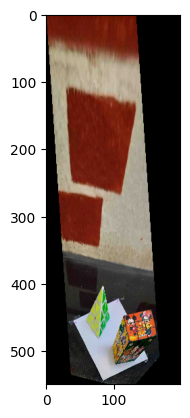

In [ ]:
# Do affine rectification
img_2 = cv.warpPerspective(img_up,H_ua ,dsize=(200,550))
plt.imshow(img_2)

In [ ]:
#Q4: Now measure the angles and lenghts
# Since the image is left only with similarity transform
# angles and ratios of lenghts are preserved between the original
# plan of the paper and the image of the paper.

H_ud = H_ua @ H_up

a1 = H_ud @ a
#################
#YOUR CODE HERE

print("Angle of paper @ vertex a =",
      #YOUR CODE HERE,
      " degrees")

#YOUR CODE HERE

print("Angle  of tetrahedron face @ vertex i =",
      #YOUR CODE HERE,
      " degrees")
print("Length of tetrahedron=",
      #YOUR CODE HERE,
      "cm")

#YOUR CODE HERE



print("Angle of cube face @ vertex e =",
      #YOUR CODE HERE,
      " degrees")
print("Length of Cube=",
      #YOUR CODE HERE,
      "cm")

Angle of paper @ vertex a = 90.00000000000024  degrees
Angle  of tetrahedron face @ vertex i = 63.43599692939583  degrees
Length of tetrahedron= 9.955337596319858 cm
Angle of cube face @ vertex e = 90.35135853155029  degrees
Length of Cube= 8.073459184877665 cm


Q5: List the possible sources of errors in the estimation
The angles are 90, 60, 90 for the paper tetrahedron and cuboid
respectively.
The lenghts are 9.9cm and 8.2cm for the tetrahedron and cuboid respectively.

#Write your answer here